## Gradient Descent

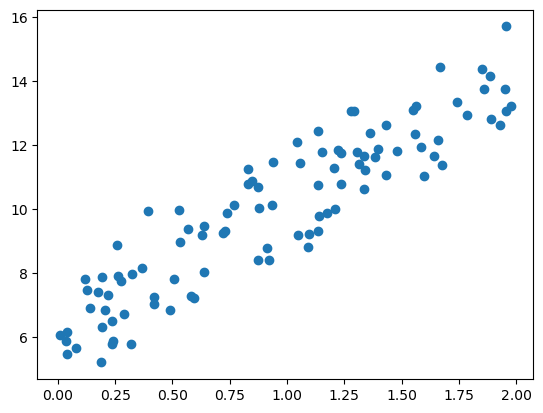

In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
X = 2 * np.random.rand(100,1) # np.random.rand(100,1) usually generates numbers between -3 and 3
y = 6 + 4 * X + np.random.randn(100,1)

plt.scatter(X,y)

In [17]:
def mse(y, y_pred): # mse
    return np.sum(np.square(y-y_pred)/len(y))

In [18]:
def update_weights(w1,w0,X,y,learning_rate=0.01):
    N = len(y)

    w1_update = np.zeros_like(w1) # zeros_like: Return an array of zeros with the same shape and type as a given array.
    w0_update = np.zeros_like(w0)

    y_pred = np.dot(X,w1.T) + w0 # when using dot product, we need to transpose one of the matrices
    diff = y - y_pred

    w0_factors = np.ones((N,1)) # dummy input for w0
    w1_update = -(2/N)*learning_rate*(np.dot(diff.T,X)) # 2/N for normalization
    w0_update = -(2/N)*learning_rate*(np.dot(diff.T,w0_factors))

    return w1_update, w0_update

In [19]:
def gradient_descent_steps(X,y,iters=10000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))

    for ind in range(iters):
        w1_update, w0_update = update_weights(w1,w0,X,y,learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

In [20]:
w1, w0 = gradient_descent_steps(X,y)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0],w0[0,0]))

y_pred = w1[0,0] * X + w0
print("Gradient Descent Total Cost:{0:.4f}".format(mse(y,y_pred)))

w1:3.968 w0:6.222
Gradient Descent Total Cost:0.9924


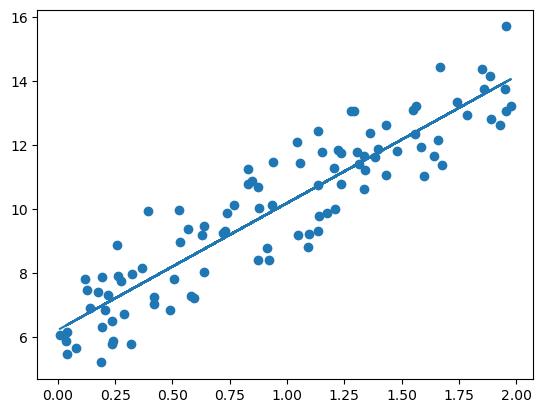

In [21]:
plt.scatter(X,y)
plt.plot(X,y_pred)

In [22]:
def stochastic_gradient_descent_steps(X,y,batch_size=10,iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_history = []

    for ind in range(iters):
        np.random.seed(ind)
        stochastic_random_index = np.random.permutation(X.shape[0]) # chaning the order of the array randomly
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]

        w1_update, w0_update = update_weights(w1,w0,sample_X,sample_y,learning_rate=0.01)
        w1 -= w1_update
        w0 -= w0_update

    return w1, w0

w1:4.028 w0:6.156
Stochastic Gradient Descent Total Cost:0.9937


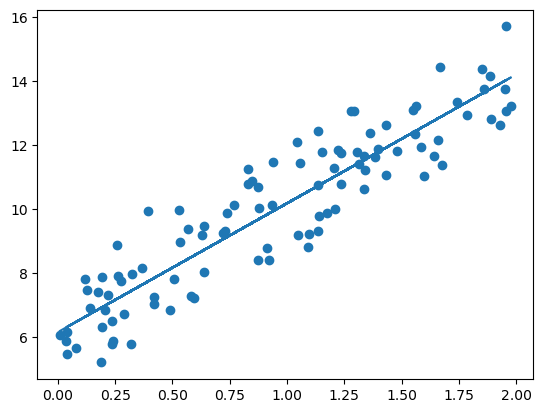

In [27]:
w1, w0 = stochastic_gradient_descent_steps(X,y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0],w0[0,0]))

y_pred = w1[0,0] * X + w0
print("Stochastic Gradient Descent Total Cost:{0:.4f}".format(mse(y,y_pred)))
plt.scatter(X,y)
plt.plot(X,y_pred)

## Scikit-learn LinearRegression

LinearRegression is a class in sklearn.linear_model.
<br>
It is a OLS(Ordinary Least Squares) method which calculates RSS(Residual Sum of Squares) of the label and the predicted value.

<br>

The scoring method of LinearRegression:

$MAE$: `sklearn.metrics.mean_absolute_error`

$MSE$: `sklearn.metrics.mean_squared_error(squared=True)`

$RMSE$: `sklearn.metrics.mean_squared_error(squared=False)`

$R^2$: `sklearn.metrics.r2_score`

<br>

we use negative value for the scoring methods (except for `r2_score`) because sklearn automatically detects the bigger value as better.
<br>
However, in this case, since the value is 'loss', smaller value is better. So we introduce using negative value instead for scoring methods.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [104]:
# load_boston is deprecated due to ethical issues https://scikit-learn.org/1.0/modules/generated/sklearn.datasets.load_boston.html
# Download source: https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset
# Using this dataset soley for **educational** purpose

bostonDF = pd.read_csv('/mnt/c/Users/USER/Downloads/boston/BostonHousing.csv')
bostonDF.rename(columns={'crim':'CRIM', 'zn':'ZN', 'indus':'INDUS', 'chas':'CHAS', 'nox':'NOX', 
                         'rm':'RM', 'age':'AGE', 'dis':'DIS', 'rad':'RAD', 'tax':'TAX', 'ptratio':'PTRATIO', 
                         'b':'B', 'lstat':'LSTAT', 'medv':'MEDV'}, inplace=True)
bostonDF.rename(columns={'MEDV':'PRICE'}, inplace=True)

# drop the column 'B' and 'LSTAT' due to ethical issues
bostonDF = bostonDF.drop(columns=['B', 'LSTAT'])

# In this dataset, 5 rooms turned out to be null values. Fill them with the mean of the column.
bostonDF.fillna(bostonDF.mean(), inplace=True)

bostonDF.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,36.2


In [98]:
# Check if there are any null values in the dataset
bostonDF.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
PRICE      0
dtype: int64

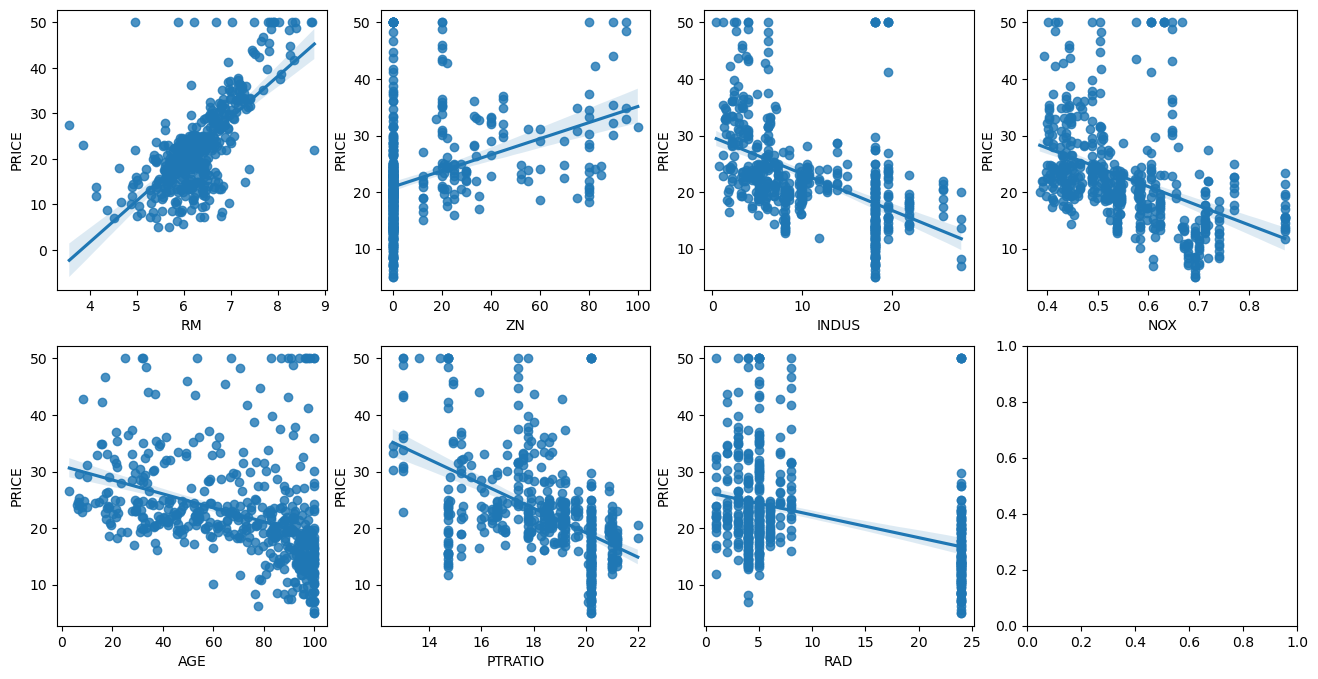

In [99]:
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4

    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3,
                                                    random_state=156)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE: {0:.3f}, RMSE: {1:.3f}'.format(mse, rmse))
print('Variance score: {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE: 20.633, RMSE: 4.542
Variance score: 0.710


In [101]:
print('절편 값:', lr.intercept_)
print('회귀 계수 값:', np.round(lr.coef_, 1))


절편 값: 33.48214346629377
회귀 계수 값: [ -0.2   0.1  -0.    3.8 -27.3   5.7  -0.   -1.8   0.4  -0.   -1.1]


In [102]:
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns)
coeff.sort_values(ascending=False)

RM          5.7
CHAS        3.8
RAD         0.4
ZN          0.1
INDUS      -0.0
TAX        -0.0
AGE        -0.0
CRIM       -0.2
PTRATIO    -1.1
DIS        -1.8
NOX       -27.3
dtype: float64

In [103]:
from sklearn.model_selection import cross_val_score
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores: ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE: {0:.3f}'.format(avg_rmse))
    

 5 folds 의 개별 Negative MSE scores:  [-11.05 -31.35 -40.92 -95.12 -46.86]
 5 folds 의 개별 RMSE scores:  [3.32 5.6  6.4  9.75 6.85]
 5 folds 의 평균 RMSE: 6.384


## 5 Polynomial Linear Regression & Underfitting & Overfitting



polynomial regression is STILL linear regression.

In [88]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(4).reshape(2,2)
print('일차 방정식 계수 feature: \n', X)

poly = PolynomialFeatures(degree=2)
poly.fit(X)
X_poly = poly.transform(X)
print('2차 방정식 계수 feature: \n', X_poly)

일차 방정식 계수 feature: 
 [[0 1]
 [2 3]]
2차 방정식 계수 feature: 
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [89]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature: \n', X)
y = polynomial_func(X)
print('삼차차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차차 다항식 결정값: 
 [  5 125]


In [90]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n', poly_ftr)


model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape\n', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape
 (10,)


In [105]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                 ('linear', LinearRegression())])

X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X,y)

print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]



Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE는 0.4077289625098685 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE는 0.04320874987232064 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899390e+05 -1.87416123e+06  2.03716219e+07
 -1.44873283e+08  7.09315363e+08 -2.47065792e+09  6.24561050e+09
 -1.15676510e+10  1.56894936e+10 -1.54006023e+10  1.06457264e+10
 -4.91377530e+09  1.35919645e+09 -1.70380786e+08] 입니다.
Degree 15 MSE는 181238256.56423894 입니다.


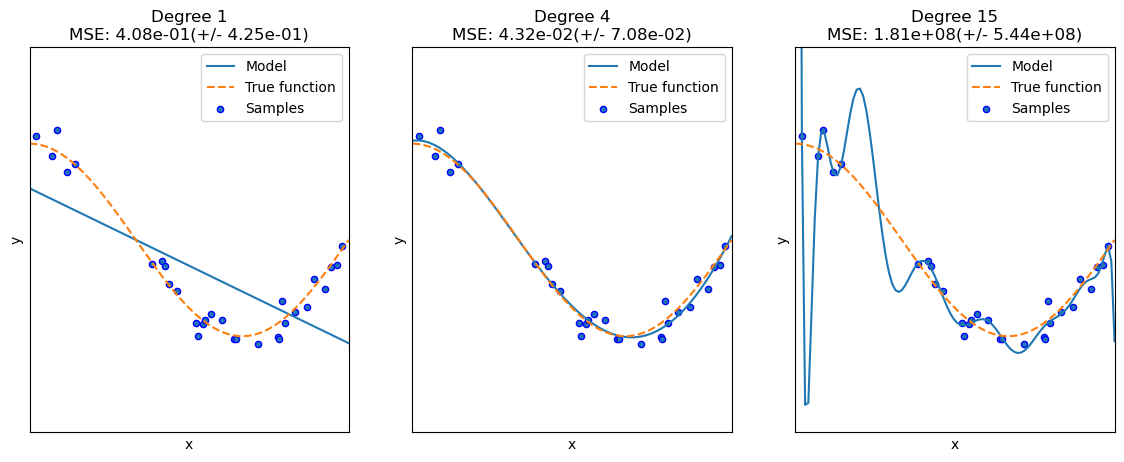

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

y= true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14,5))

degrees = [1,4,15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i+1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([('polynomial_features', polynomial_features),
                        ('linear_regression', linear_regression)])
    pipeline.fit(X.reshape(-1,1), y)

    scores = cross_val_score(pipeline, X.reshape(-1,1), y, scoring="neg_mean_squared_error", cv=10)
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
    
    X_test = np.linspace(0,1,100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0,1)); plt.ylim((-2,2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE: {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

plt.show()